## Imports & config

In [1]:
# Cell 1
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

RANDOM_STATE = 42

plt.style.use("default")
plt.rcParams.update({"figure.figsize": (7,4), "axes.grid": True, "grid.alpha":0.25})


## Load data & define columns

In [2]:
# Cell 2
df = pd.read_csv("synthetic_pnc_claims_regression.csv", parse_dates=["Date_of_Loss","Report_Date"])

TARGET = "Total_Paid_Amount"

cat_cols = ["Coverage_Type","Insurance_Score_Band","Vehicle_Segment","Urbanicity",
            "Collision_Type","Weather_At_LOSS","At_Fault_Indicator"]
bool_cols = ["Injury_Indicator","Multi_Vehicle_Flag","Attorney_Rep_At_FNOL"]
num_cols  = ["Bodily_Injury_Limit_Per_Person","Property_Damage_Limit","Collision_Deductible",
             "Policy_Tenure_Months","Driver_Age","Vehicle_Age_Years","Vehicle_ACV",
             "Repair_Cost_Index","Medical_Cost_Index","Weather_Cat_Risk_Index",
             "Report_Lag_Days","Prior_Claims_Count_36M","Moving_Violations_36M"]

X = df[cat_cols + bool_cols + num_cols].copy()
y = df[TARGET].astype(float)

print("Shape:", X.shape, "Target describe:\n", y.describe())


Shape: (20000, 23) Target describe:
 count    20000.000000
mean      4345.201280
std       4422.455378
min          0.000000
25%       1706.082500
50%       3298.610000
75%       5469.347500
max      90686.090000
Name: Total_Paid_Amount, dtype: float64


## Train/test split

In [3]:
# Cell 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
len(X_train), len(X_test)


(16000, 4000)

## Preprocessing (OHE + scaling), baseline model

In [4]:
# Cell 4
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()

preprocess = ColumnTransformer(
    transformers=[
        ("num", scaler, num_cols),
        ("cat", ohe, cat_cols),
        ("bool", "passthrough", bool_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Baseline powerful regressor (built-in, tree-based, handles nonlinearity well)
hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)

pipe = Pipeline([("prep", preprocess), ("model", hgb)])
pipe


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Bodily_Injury_Limit_Per_Person',
                                                   'Property_Damage_Limit',
                                                   'Collision_Deductible',
                                                   'Policy_Tenure_Months',
                                                   'Driver_Age',
                                                   'Vehicle_Age_Years',
                                                   'Vehicle_ACV',
                                                   'Repair_Cost_Index',
                                                   'Medical_Cost_Index',
                                                   'Weather_Cat_Risk_Index',
                                                   'Report_Lag_Days',
                                                   'Prior_Claims_Count_36M',
                                                   'Moving_Vi...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Coverage_Type',
                                                   'Insurance_Score_Band',
                                                   'Vehicle_Segment',
                                                   'Urbanicity',
                                                   'Collision_Type',
                                                   'Weather_At_LOSS',
                                                   'At_Fault_Indicator']),
                                                 ('bool', 'passthrough',
                                                  ['Injury_Indicator',
                                                   'Multi_Vehicle_Flag',
                                                   'Attorney_Rep_At_FNOL'])],
                                   verbose_feature_names_out=False)),
                ('model', HistGradientBoostingRegressor(random_state=42))])

## Cross-validated baseline performance (no tuning)

In [5]:
# Cell 5
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}
cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_estimator=False)
print("CV R2   :", cv_res["test_r2"].mean().round(4), "+/-", cv_res["test_r2"].std().round(4))
print("CV RMSE :", (-cv_res["test_rmse"]).mean().round(2))
print("CV MAE  :", (-cv_res["test_mae"]).mean().round(2))


CV R2   : 0.658 +/- 0.0311
CV RMSE : 2627.68
CV MAE  : 1508.58


## Hyperparameter tuning (RandomizedSearchCV for HGB)

In [6]:
# Cell 6
param_dist = {
    "model__learning_rate":  np.logspace(-3, -1, 20),
    "model__max_depth":      [None, 3, 4, 5, 6, 7, 8],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf":[10, 20, 50, 100],
    "model__l2_regularization": np.logspace(-6, 0, 10),
}
search = RandomizedSearchCV(
    pipe, param_distributions=param_dist, n_iter=40, scoring="r2",
    cv=cv, verbose=1, n_jobs=-1, random_state=RANDOM_STATE
)
search.fit(X_train, y_train)

print("Best R2 (CV):", round(search.best_score_, 4))
print("Best params:", search.best_params_)
best_model = search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best R2 (CV): 0.6595
Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_depth': 5, 'model__learning_rate': 0.04832930238571752, 'model__l2_regularization': 0.21544346900318823}


## Save model

In [11]:
import joblib, json, os

MODEL_PATH = "claims_severity_hgb_pipeline.joblib"
joblib.dump(best_model, MODEL_PATH)
print(f"Saved: {MODEL_PATH}")

# (Optional) save the train-time schema you used
schema = {
    "target": TARGET,
    "categorical": cat_cols,
    "booleans": bool_cols,
    "numerical": num_cols
}
with open("claims_severity_schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print("Saved: claims_severity_schema.json")

# How to load later:
# best_model = joblib.load(MODEL_PATH)
# y_pred = best_model.predict(X_new)


Saved: claims_severity_hgb_pipeline.joblib
Saved: claims_severity_schema.json


## Train metrics (CV) vs Test metrics

In [14]:
# Cell 7
# Refit already done; evaluate on held-out test set
y_pred_test = best_model.predict(X_test)

def regression_report(y_true, y_pred, label=""):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    print(f"{label}R²={r2:.4f} | RMSE={rmse:,.2f} | MAE={mae:,.2f} | MAPE={mape:.2f}%")

# CV score already shown; now test:
print("=== Test set ===")
regression_report(y_test, y_pred_test, label="")



=== Test set ===
R²=0.6889 | RMSE=2,298.82 | MAE=1,417.93 | MAPE=2370606410.41%


## Metrics / scores

In [23]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

def metrics_regression_core(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    wape = mae / max(y_true.mean(), 1e-6) * 100.0

    # RMSLE on clipped positives for stability
    y_true_pos = np.clip(y_true, 1e-6, None)
    y_pred_pos = np.clip(y_pred, 1e-6, None)
    rmsle = mean_squared_error(np.log1p(y_true_pos), np.log1p(y_pred_pos), squared=False)

    return {"R2": r2, "RMSE": rmse, "MAE": mae, "WAPE%": wape, "RMSLE": rmsle}

def metrics_regression_optional(y_true, y_pred, mape_floor=50.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    medae = median_absolute_error(y_true, y_pred)

    # SMAPE (bounded, handles zeros)
    smape = np.mean(2.0 * np.abs(y_pred - y_true) /
                    np.clip(np.abs(y_true) + np.abs(y_pred), 1e-6, None)) * 100.0

    # Thresholded MAPE
    mask = y_true >= float(mape_floor)
    mape_thresh = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0
                   if mask.any() else np.nan)

    return {"MedAE": medae, "SMAPE%": smape, f"MAPE%@>=${int(mape_floor)}": mape_thresh}

def print_metric_row(name, d):
    parts = []
    for k,v in d.items():
        if k == "R2":
            parts.append(f"{k}={v:.4f}")
        elif k.endswith("%"):
            parts.append(f"{k}={v:.2f}%")
        else:
            parts.append(f"{k}={v:,.4f}" if abs(v)<1000 else f"{k}={v:,.2f}")
    print(f"{name:>6} | " + " | ".join(parts))

# --- usage (assuming best_model, X_train, X_test, y_train, y_test from prior cells) ---
yhat_tr = best_model.predict(X_train)
yhat_te = best_model.predict(X_test)

core_tr = metrics_regression_core(y_train, yhat_tr)
core_te = metrics_regression_core(y_test,  yhat_te)

print_metric_row("Train", core_tr)
print_metric_row("Test ", core_te)

# If you want the optional diagnostics:
opt_tr = metrics_regression_optional(y_train, yhat_tr, mape_floor=50.0)
opt_te = metrics_regression_optional(y_test,  yhat_te, mape_floor=50.0)

print_metric_row("Train*", opt_tr)  # optional
print_metric_row("Test *", opt_te)  # optional


 Train | R2=0.7139 | RMSE=2,403.71 | MAE=1,420.07 | WAPE%=32.51% | RMSLE=1.3222
 Test  | R2=0.6889 | RMSE=2,298.82 | MAE=1,417.93 | WAPE%=33.32% | RMSLE=1.3705
Train* | MedAE=904.5667 | SMAPE%=42.40% | MAPE%@>=$50=49.7164
Test * | MedAE=915.9533 | SMAPE%=43.86% | MAPE%@>=$50=53.8907


R² — Coefficient of Determination

	What: Fraction of variance in the target explained by the model; 1.0 is perfect, 0.0 ≈ predicting the mean, negative = worse than the mean.

	Why: Single “goodness-of-fit” number that stakeholders recognize; scale-invariant, easy to compare models on the same dataset.

RMSE — Root Mean Squared Error

	What: Square root of average squared error (same units as the target). Penalizes large errors more than small ones.

	Why: Great when big misses are costly (e.g., high-severity claims). Easy to set tolerances in dollars.

MAE — Mean Absolute Error

	What: Average absolute error (same units as the target).

	Why: Robust and intuitive “average miss in dollars.” Less sensitive to outliers than RMSE.

WAPE — Weighted Absolute Percentage Error (a.k.a. MAE/mean)

	Why: A stable, portfolio-level percentage error. Unlike MAPE, it doesn’t explode on zeros and is easy to explain (“on average we’re off by ~33% of typical claim size”).

RMSLE — Root Mean Squared Log Error

	What: RMSE computed on log(1 + value).

	Why: Handles right-tailed severities; focuses on relative error (under/over-prediction by a factor) and is stable with wide ranges.	

## Diagnostic plots (Pred vs Actual, Residuals)

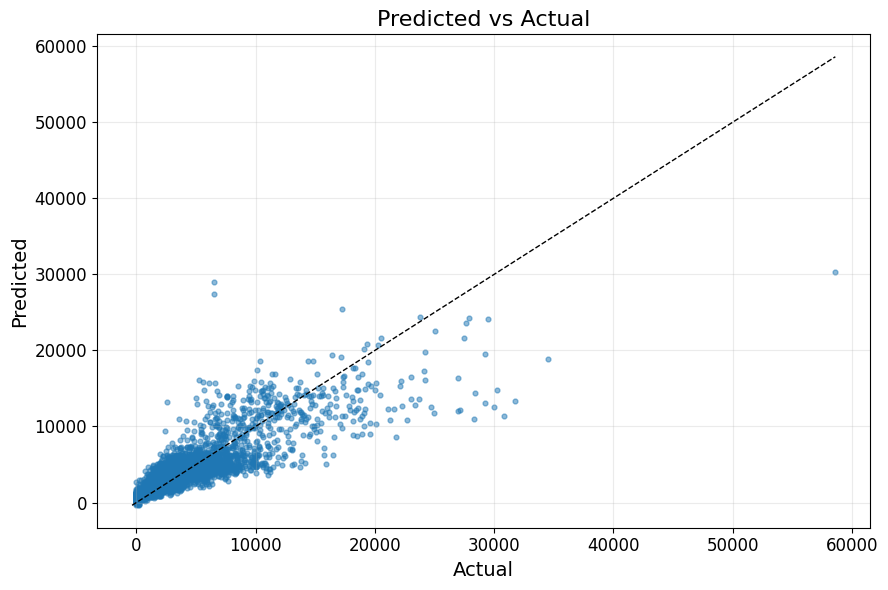

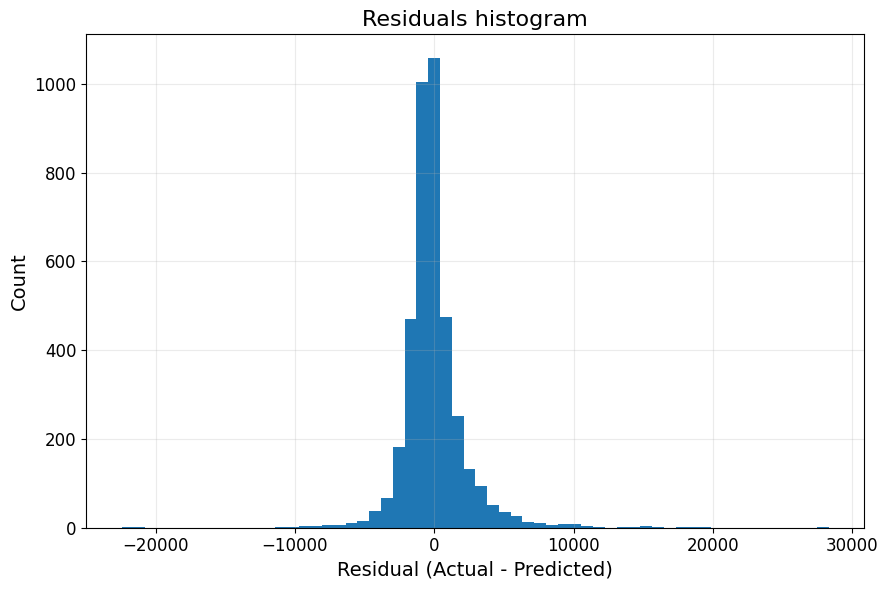

In [10]:
import matplotlib.pyplot as plt

plt.style.use("default")  # white bg
plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Predicted vs Actual
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_test, s=12, alpha=0.5)
_min, _max = float(min(y_test.min(), y_pred_test.min())), float(max(y_test.max(), y_pred_test.max()))
ax.plot([_min, _max], [_min, _max], "k--", lw=1)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
fig.set_facecolor("white")
plt.tight_layout(); plt.show()

# Residuals
resid = y_test - y_pred_test
fig, ax = plt.subplots()
ax.hist(resid, bins=60)
ax.set_title("Residuals histogram")
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
fig.set_facecolor("white")
plt.tight_layout(); plt.show()


## Permutation importance (model-agnostic, post-OHE)

Injury_Indicator                0.480472
Coverage_Type_Liability         0.244392
Coverage_Type_Comprehensive     0.159764
Coverage_Type_Collision         0.126405
Collision_Type_HeadOn           0.122598
Vehicle_ACV                     0.096453
Coverage_Type_PIP               0.080410
Collision_Type_Angle            0.068552
Coverage_Type_UM_UIM            0.038413
Repair_Cost_Index               0.024017
Collision_Type_Parked           0.015925
Medical_Cost_Index              0.011467
Collision_Type_SingleVehicle    0.006960
At_Fault_Indicator_Insured      0.004372
Attorney_Rep_At_FNOL            0.003344
Moving_Violations_36M           0.002613
Collision_Deductible            0.002146
Weather_Cat_Risk_Index          0.002035
Collision_Type_RearEnd          0.001966
Weather_At_LOSS_Clear           0.001243
dtype: float64


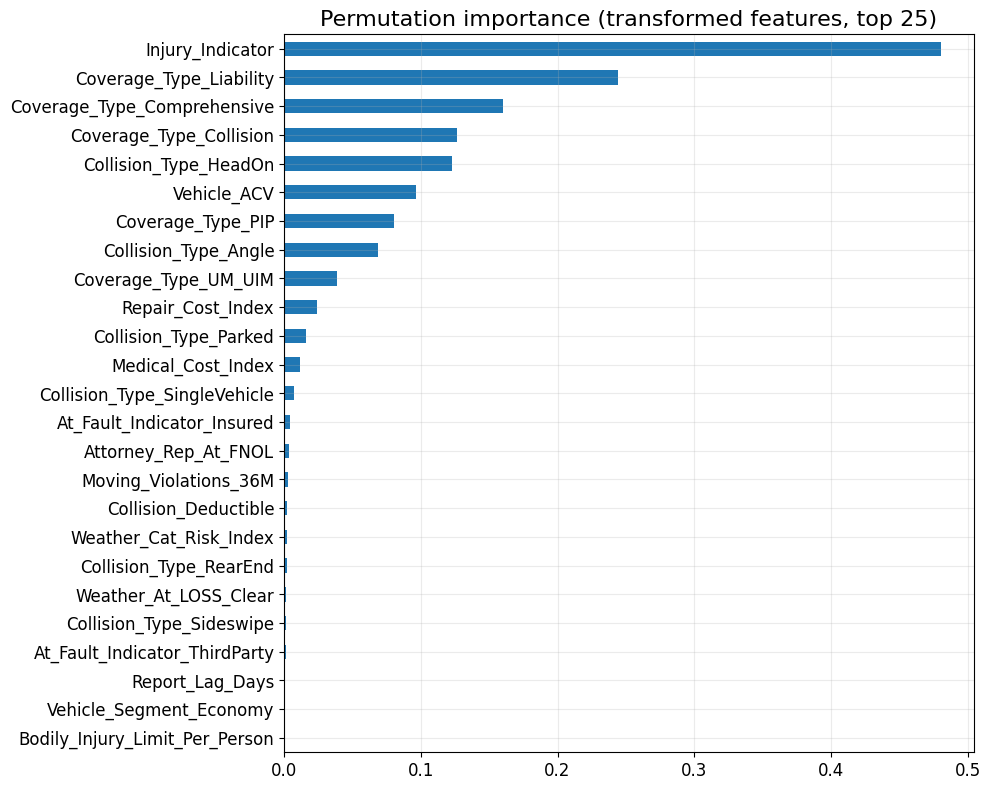

In [24]:
# Use the preprocessor to transform X, and run PI on the final regressor only
prep = best_model.named_steps["prep"]
reg  = best_model.named_steps["model"]

# Transformed matrix and aligned feature names
X_test_tx = prep.transform(X_test)
try:
    # sklearn >= 1.1
    tx_feature_names = prep.get_feature_names_out()
except AttributeError:
    # fallback if older sklearn
    from sklearn.compose import ColumnTransformer
    tx_feature_names = np.array(
        list(np.array(num_cols)) +
        list(prep.named_transformers_["cat"].get_feature_names_out(cat_cols)) +
        list(bool_cols)
    )

from sklearn.inspection import permutation_importance
r = permutation_importance(reg, X_test_tx, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)

imp = pd.Series(r.importances_mean, index=tx_feature_names).sort_values(ascending=False)

print(imp.head(20))
top = imp.head(25)
plt.figure(figsize=(10,8))
top.iloc[::-1].plot(kind="barh")
plt.title("Permutation importance (transformed features, top 25)")
plt.tight_layout(); plt.show()


## Compute metrics

In [25]:
# Cell 1
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

def metrics_core(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    wape = mae / max(y_true.mean(), 1e-6) * 100.0
    # RMSLE on clipped positives for stability
    ytp = np.clip(y_true, 1e-6, None); ypp = np.clip(y_pred, 1e-6, None)
    rmsle = mean_squared_error(np.log1p(ytp), np.log1p(ypp), squared=False)
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "WAPE%": wape, "RMSLE": rmsle}

def metrics_optional(y_true, y_pred, mape_floor=50.0):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    medae = median_absolute_error(y_true, y_pred)
    smape = np.mean( 2.0*np.abs(y_pred - y_true) / np.clip(np.abs(y_true)+np.abs(y_pred), 1e-6, None) )*100.0
    mask = y_true >= float(mape_floor)
    mape_thresh = (np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask]))*100.0) if mask.any() else np.nan
    return {"MedAE": medae, "SMAPE%": smape, f"MAPE%@>=${int(mape_floor)}": mape_thresh}

# assuming best_model, X_train, X_test, y_train, y_test exist from earlier cells
yhat_tr = best_model.predict(X_train)
yhat_te = best_model.predict(X_test)

core_tr = metrics_core(y_train, yhat_tr)
core_te = metrics_core(y_test,  yhat_te)
opt_tr  = metrics_optional(y_train, yhat_tr, mape_floor=50.0)
opt_te  = metrics_optional(y_test,  yhat_te, mape_floor=50.0)

pd.DataFrame([core_tr, core_te], index=["Train","Test"])


,R2,RMSE,MAE,WAPE%,RMSLE
Train,0.713929,2403.709405,1420.073741,32.513436,1.322198
Test,0.688904,2298.817977,1417.930669,33.320749,1.370451


## Nice Train vs Test bar chart per metric

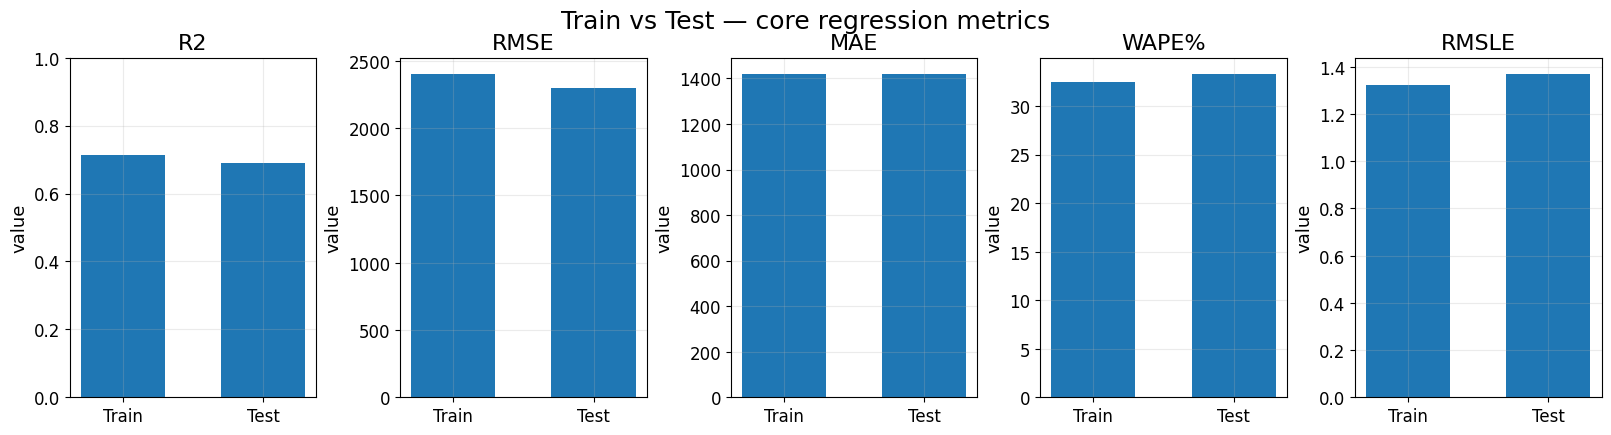

In [26]:
# Cell 2
import matplotlib.pyplot as plt
plt.style.use("default")
plt.rcParams.update({"figure.figsize": (8,5), "axes.titlesize": 16, "axes.labelsize": 13,
                     "xtick.labelsize": 12, "ytick.labelsize": 12, "axes.grid": True, "grid.alpha": .25})

core_df = pd.DataFrame([core_tr, core_te], index=["Train","Test"])
# Ensure order you want on the chart:
core_df = core_df[["R2","RMSE","MAE","WAPE%","RMSLE"]]

fig, axes = plt.subplots(1, core_df.shape[1], figsize=(16,4), constrained_layout=True)
for ax, metric in zip(axes, core_df.columns):
    ax.bar(core_df.index, core_df[metric], width=0.6)
    ax.set_title(metric)
    if metric == "R2":
        ax.set_ylim(0, 1)  # R2 bounded (usually)
    ax.set_ylabel("value")
plt.suptitle("Train vs Test — core regression metrics", y=1.05, fontsize=18)
plt.show()


## “Curve” across folds (Train vs Val per fold)

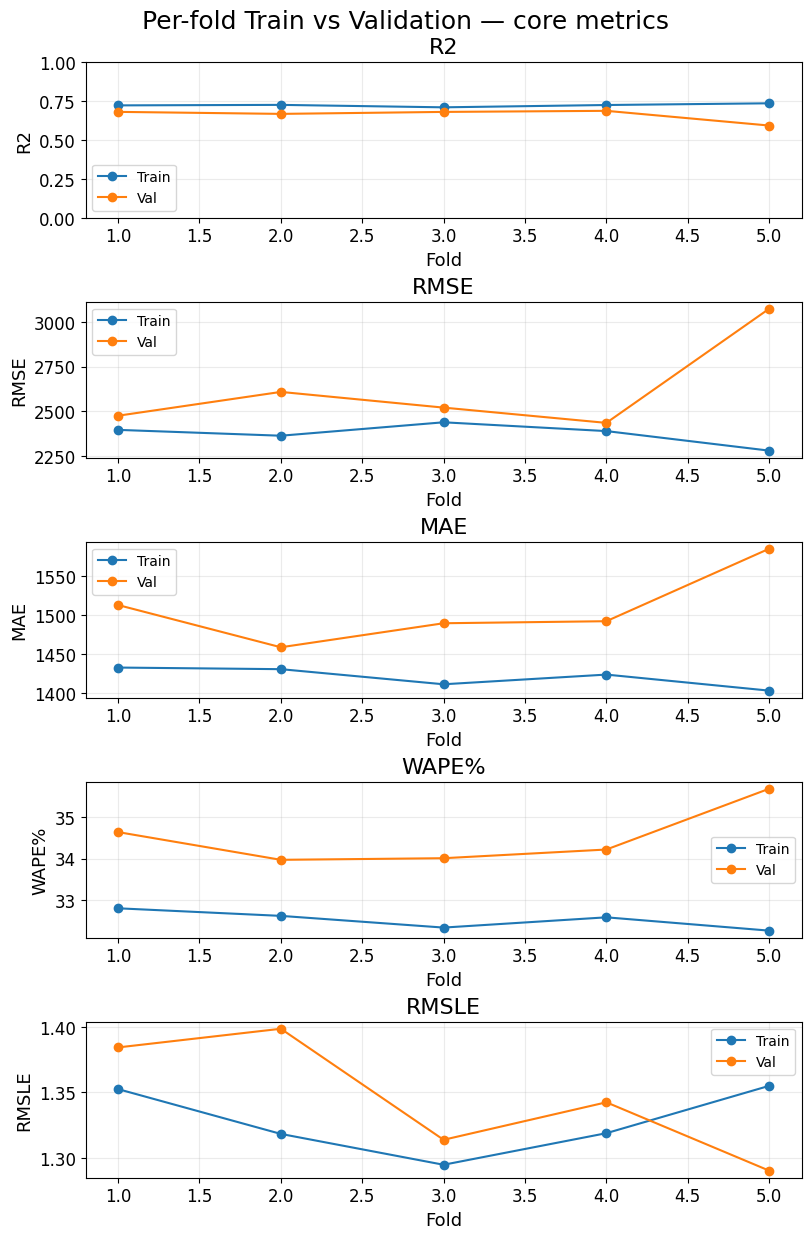

In [28]:
# Cell 4
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for i, (tr, va) in enumerate(kf.split(X_train), 1):
    Xm_tr, Xm_va = X_train.iloc[tr], X_train.iloc[va]
    ym_tr, ym_va = y_train.iloc[tr], y_train.iloc[va]
    best_model.fit(Xm_tr, ym_tr)
    pred_tr = best_model.predict(Xm_tr)
    pred_va = best_model.predict(Xm_va)
    rows.append({"fold": i, "split": "Train", **metrics_core(ym_tr, pred_tr)})
    rows.append({"fold": i, "split": "Val",   **metrics_core(ym_va, pred_va)})

cv_df = pd.DataFrame(rows)

# Plot per metric across folds
metrics_to_plot = ["R2","RMSE","MAE","WAPE%","RMSLE"]
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 12), constrained_layout=True)
for ax, m in zip(axes, metrics_to_plot):
    for split in ["Train","Val"]:
        sub = cv_df[cv_df["split"]==split]
        ax.plot(sub["fold"], sub[m], marker="o", label=split)
    ax.set_title(m); ax.set_xlabel("Fold"); ax.set_ylabel(m)
    if m == "R2": ax.set_ylim(0, 1)
    ax.legend()
plt.suptitle("Per-fold Train vs Validation — core metrics", y=1.02, fontsize=18)
plt.show()
